In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("public_transport_delays.csv")

In [3]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [4]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [7]:
len(df)

2000

In [8]:
c = df.groupby('event_type')['event_type'].count()
c

event_type
Concert     203
Festival    221
Parade      105
Protest      86
Sports      212
Name: event_type, dtype: int64

In [9]:
df['event_type'].unique()

<StringArray>
[nan, 'Sports', 'Protest', 'Parade', 'Concert', 'Festival']
Length: 6, dtype: str

In [10]:
df['event_type'] = df['event_type'].fillna("NO Event")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [12]:
pd.to_datetime(df['date'])
pd.to_datetime(df['time'])

C:\Users\praka\AppData\Local\Temp\ipykernel_10216\818874788.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df['time'])


0      2026-04-06 05:00:00
1      2026-04-06 05:15:00
2      2026-04-06 05:30:00
3      2026-04-06 05:45:00
4      2026-04-06 06:00:00
               ...        
1995   2026-04-06 23:45:00
1996   2026-04-06 00:00:00
1997   2026-04-06 00:15:00
1998   2026-04-06 00:30:00
1999   2026-04-06 00:45:00
Name: time, Length: 2000, dtype: datetime64[us]

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [14]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [15]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NO Event,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NO Event,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NO Event,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NO Event,500,46,0,0,6,Spring,1


In [16]:
df.isnull().sum()

trip_id                       0
date                          0
time                          0
transport_type                0
route_id                      0
origin_station                0
destination_station           0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
weather_condition             0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_type                    0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
season                        0
delayed                       0
dtype: int64

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [18]:
df['weather_condition'].unique()

<StringArray>
['Storm', 'Rain', 'Clear', 'Snow', 'Fog', 'Cloudy']
Length: 6, dtype: str

In [19]:
df['season'].unique()

<StringArray>
['Winter', 'Autumn', 'Spring', 'Summer']
Length: 4, dtype: str

In [20]:
a = df.groupby('actual_arrival_delay_min')['actual_arrival_delay_min'].count()
a

actual_arrival_delay_min
-3     55
-2     61
-1     49
 0     55
 1     50
 2     57
 3     55
 4     62
 5     57
 6     58
 7     49
 8     45
 9     65
 10    76
 11    84
 12    64
 13    66
 14    67
 15    62
 16    69
 17    66
 18    66
 19    64
 20    51
 21    53
 22    58
 23    69
 24    75
 25    56
 26    61
 27    63
 28    65
 29    47
Name: actual_arrival_delay_min, dtype: int64

In [21]:
df['peak_hour'].head(15)

0     1
1     0
2     0
3     0
4     0
5     0
6     1
7     0
8     0
9     0
10    0
11    0
12    0
13    1
14    0
Name: peak_hour, dtype: int64

In [22]:
df['peak_hour'] = df['peak_hour'].replace({1: 'peak', 0: "non-Peak"})


In [23]:
df['peak_hour'].head()

0        peak
1    non-Peak
2    non-Peak
3    non-Peak
4    non-Peak
Name: peak_hour, dtype: object

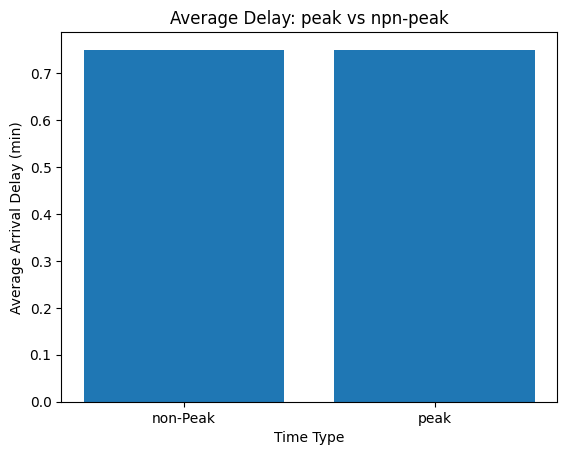

In [24]:
avg_delay = df.groupby('peak_hour')['delayed'].mean()
plt.bar(['non-Peak', 'peak'], avg_delay)
plt.xlabel('Time Type')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay: peak vs npn-peak')
plt.show()

In [25]:
df['traffic_level'] = pd.cut(df['traffic_congestion_index'],
                                       bins=[0, 20, 40, 60, 80, 100],
                                       labels=['low', 'medium', 'high', 'very_high', 'extreme'])

In [26]:
df['traffic_level'].head()

0      extreme
1         high
2    very_high
3      extreme
4         high
Name: traffic_level, dtype: category
Categories (5, str): ['low' < 'medium' < 'high' < 'very_high' < 'extreme']

In [27]:
avg_delay = df.groupby('traffic_level')['actual_arrival_delay_min'].mean()

<BarContainer object of 5 artists>

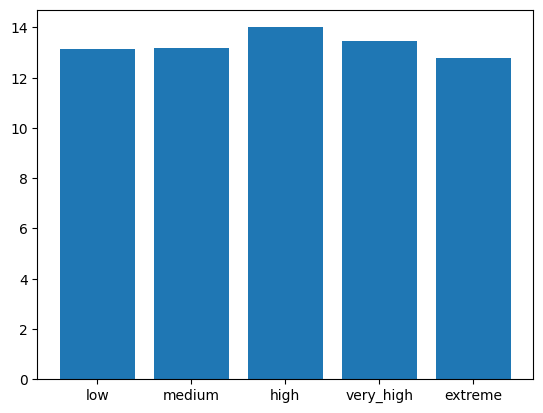

In [28]:
plt.bar(avg_delay.index, avg_delay.values) 

In [29]:
weather_delay = df.groupby('weather_condition')['actual_arrival_delay_min'].mean()

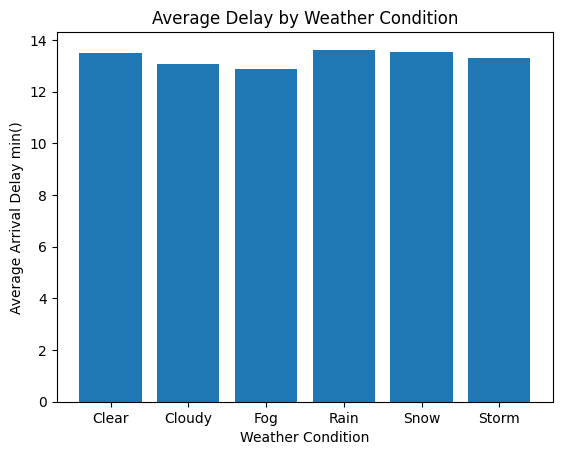

In [30]:
plt.bar(weather_delay.index, weather_delay.values)
plt.title('Average Delay by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Arrival Delay min()')
plt.show()

In [31]:
event_analysis = df.groupby('event_type')['actual_arrival_delay_min'].mean()
event_analysis

event_type
Concert     12.832512
Festival    12.769231
NO Event    13.526002
Parade      13.619048
Protest     13.895349
Sports      12.820755
Name: actual_arrival_delay_min, dtype: float64

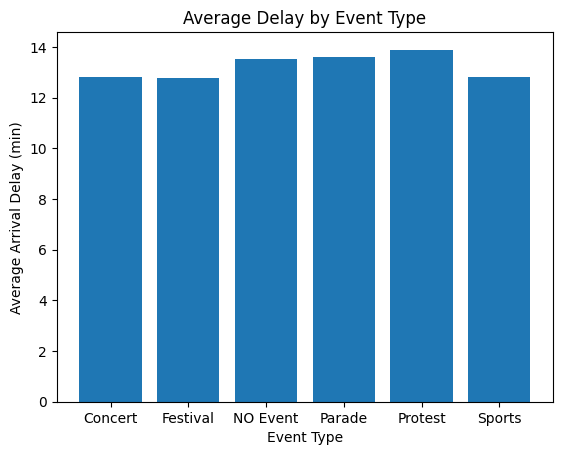

In [32]:
plt.bar(event_analysis.index, event_analysis.values)
plt.xlabel('Event Type')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay by Event Type')
plt.show()

In [33]:
df['event_attendance_est'].unique()

array([  500,     0, 50000,  2000, 10000])

In [34]:
df['attendas_level'] = df['event_attendance_est'].replace({
    0: 'no_event',
    500: 'small',
    2000: 'medium',
    10000: 'large',
    50000: 'huge'
})

In [35]:
attendance_analysis = df.groupby('attendas_level')['actual_arrival_delay_min'].mean()
attendance_analysis

attendas_level
huge        14.204762
large       13.754098
medium      14.404762
no_event    12.990132
small       12.790055
Name: actual_arrival_delay_min, dtype: float64

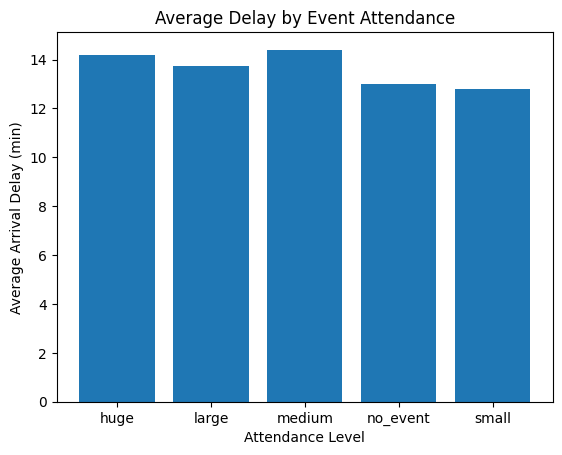

In [36]:

plt.bar(attendance_analysis.index, attendance_analysis.values)
plt.xlabel('Attendance Level')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay by Event Attendance')
plt.show()

In [37]:
pd.to_datetime(df['time'])
df

C:\Users\praka\AppData\Local\Temp\ipykernel_10216\1317857667.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df['time'])


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,traffic_level,attendas_level
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,NO Event,500,81,0,peak,6,Winter,0,extreme,small
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,NO Event,0,53,0,non-Peak,6,Autumn,1,high,no_event
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,Sports,0,67,1,non-Peak,6,Autumn,0,very_high,no_event
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,NO Event,500,84,0,non-Peak,6,Winter,1,extreme,small
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,NO Event,500,46,0,non-Peak,6,Spring,1,high,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,T01995,2023-01-21,23:45:00,Bus,Route_11,Station_46,Station_39,23:46:00,00:11:00,15,...,NO Event,0,96,0,non-Peak,5,Winter,1,extreme,no_event
1996,T01996,2023-01-22,00:00:00,Train,Route_9,Station_44,Station_42,00:03:00,00:41:00,11,...,Festival,0,12,0,peak,6,Winter,1,low,no_event
1997,T01997,2023-01-22,00:15:00,Bus,Route_12,Station_4,Station_45,00:18:00,00:35:00,1,...,NO Event,0,24,1,non-Peak,6,Summer,1,medium,no_event
1998,T01998,2023-01-22,00:30:00,Tram,Route_17,Station_29,Station_48,00:34:00,01:18:00,7,...,NO Event,2000,23,0,non-Peak,6,Summer,1,medium,medium


In [38]:
df = df.drop(columns=['trip_id', 'route_id', 'origin_station', 'destination_station'])

In [39]:
df

,date,time,transport_type,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,traffic_level,attendas_level
0,2023-01-01,05:00:00,Tram,05:02:00,05:55:00,12,3,Storm,5.1,52,...,NO Event,500,81,0,peak,6,Winter,0,extreme,small
1,2023-01-01,05:15:00,Metro,05:16:00,05:55:00,15,9,Rain,34.0,64,...,NO Event,0,53,0,non-Peak,6,Autumn,1,high,no_event
2,2023-01-01,05:30:00,Bus,05:33:00,06:17:00,0,0,Clear,29.5,35,...,Sports,0,67,1,non-Peak,6,Autumn,0,very_high,no_event
3,2023-01-01,05:45:00,Tram,05:49:00,06:08:00,15,10,Clear,27.4,55,...,NO Event,500,84,0,non-Peak,6,Winter,1,extreme,small
4,2023-01-01,06:00:00,Tram,06:00:00,06:35:00,-1,14,Snow,0.1,90,...,NO Event,500,46,0,non-Peak,6,Spring,1,high,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2023-01-21,23:45:00,Bus,23:46:00,00:11:00,15,14,Storm,17.2,98,...,NO Event,0,96,0,non-Peak,5,Winter,1,extreme,no_event
1996,2023-01-22,00:00:00,Train,00:03:00,00:41:00,11,25,Snow,0.0,89,...,Festival,0,12,0,peak,6,Winter,1,low,no_event
1997,2023-01-22,00:15:00,Bus,00:18:00,00:35:00,1,21,Snow,12.9,95,...,NO Event,0,24,1,non-Peak,6,Summer,1,medium,no_event
1998,2023-01-22,00:30:00,Tram,00:34:00,01:18:00,7,9,Clear,17.8,55,...,NO Event,2000,23,0,non-Peak,6,Summer,1,medium,medium


In [40]:
df['weather_condition'].unique()

<StringArray>
['Storm', 'Rain', 'Clear', 'Snow', 'Fog', 'Cloudy']
Length: 6, dtype: str

In [41]:
df['season'].unique()

<StringArray>
['Winter', 'Autumn', 'Spring', 'Summer']
Length: 4, dtype: str

In [42]:
df['event_type'].unique()

<StringArray>
['NO Event', 'Sports', 'Protest', 'Parade', 'Concert', 'Festival']
Length: 6, dtype: str

In [43]:
df = pd.get_dummies(df, columns=['weather_condition', 'season', 'event_type', 'transport_type'])

In [44]:
df = df.dropna(subset=['traffic_level'])

In [45]:
df['peak_hour'] = df['peak_hour'].replace({'non-Peak': 0, 'peak': 1})

In [46]:
df['peak_hour'].head()

0    1
1    0
2    0
3    0
4    0
Name: peak_hour, dtype: object

In [47]:
df['attendas_level'] = df['attendas_level'].replace({'no_event': 0, 'small': 1, 'medium': 2, 'large': 3, 'huge': 4})

In [48]:
df.isnull().sum()

date                          0
time                          0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
delayed                       0
traffic_level                 0
attendas_level                0
weather_condition_Clear       0
weather_condition_Cloudy      0
weather_condition_Fog         0
weather_condition_Rain        0
weather_condition_Snow        0
weather_condition_Storm       0
season_Autumn                 0
season_Spring                 0
season_Summer                 0
season_Winter                 0
event_type_Concert            0
event_type_Festival           0
event_type_NO Event           0
event_ty

In [49]:
df['traffic_level'].unique()

['extreme', 'high', 'very_high', 'medium', 'low']
Categories (5, str): ['low' < 'medium' < 'high' < 'very_high' < 'extreme']

In [50]:
df['traffic_level'] = df['traffic_level'].astype(str)

In [51]:
df['traffic_level'] =  df['traffic_level'].replace({'extreme': 5, 'high': 4, 'very_high': 3, 'medium': 2, 'low': 1})

In [52]:
df['traffic_level'] = df['traffic_level'].astype(int)

In [53]:
df['traffic_level'].head()

0    5
1    4
2    3
3    5
4    4
Name: traffic_level, dtype: int64

In [54]:
df['attendas_level'].head()

0    1
1    0
2    0
3    1
4    1
Name: attendas_level, dtype: object

In [55]:
df['attendas_level'] = df['attendas_level'].astype(int)

In [56]:
len(df)

1981

In [73]:
df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'])

C:\Users\praka\AppData\Local\Temp\ipykernel_10216\1898863360.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'])


In [74]:
df['hour'] = df['scheduled_departure'].dt.hour

In [75]:
df['day'] = df['scheduled_departure'].dt.day

In [76]:
df['month'] = df['scheduled_departure'].dt.month

In [77]:
df['scheduled_departure'].head()

0   2026-04-06 05:02:00
1   2026-04-06 05:16:00
2   2026-04-06 05:33:00
3   2026-04-06 05:49:00
4   2026-04-06 06:00:00
Name: scheduled_departure, dtype: datetime64[us]

In [121]:
X = df.drop(['actual_departure_delay_min','delayed', 'date', 'time', 'scheduled_arrival'], axis=1)
y = df['actual_departure_delay_min']

In [122]:
X = pd.get_dummies(X, columns=['peak_hour'], drop_first=True)

In [123]:
X = pd.get_dummies(X, drop_first=True)

In [124]:
X.columns

Index(['scheduled_departure', 'actual_arrival_delay_min', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'weekday', 'traffic_level', 'attendas_level', 'weather_condition_Clear',
       'weather_condition_Cloudy', 'weather_condition_Fog',
       'weather_condition_Rain', 'weather_condition_Snow',
       'weather_condition_Storm', 'season_Autumn', 'season_Spring',
       'season_Summer', 'season_Winter', 'event_type_Concert',
       'event_type_Festival', 'event_type_NO Event', 'event_type_Parade',
       'event_type_Protest', 'event_type_Sports', 'transport_type_Bus',
       'transport_type_Metro', 'transport_type_Train', 'transport_type_Tram',
       'hour', 'day', 'month', 'peak_hour_1'],
      dtype='str')

In [125]:
y

0       12
1       15
2        0
3       15
4       -1
        ..
1995    15
1996    11
1997     1
1998     7
1999     0
Name: actual_departure_delay_min, Length: 1981, dtype: int64

In [126]:
df.columns

Index(['date', 'time', 'scheduled_departure', 'scheduled_arrival',
       'actual_departure_delay_min', 'actual_arrival_delay_min',
       'temperature_C', 'humidity_percent', 'wind_speed_kmh',
       'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
       'holiday', 'peak_hour', 'weekday', 'delayed', 'traffic_level',
       'attendas_level', 'weather_condition_Clear', 'weather_condition_Cloudy',
       'weather_condition_Fog', 'weather_condition_Rain',
       'weather_condition_Snow', 'weather_condition_Storm', 'season_Autumn',
       'season_Spring', 'season_Summer', 'season_Winter', 'event_type_Concert',
       'event_type_Festival', 'event_type_NO Event', 'event_type_Parade',
       'event_type_Protest', 'event_type_Sports', 'transport_type_Bus',
       'transport_type_Metro', 'transport_type_Train', 'transport_type_Tram',
       'hour', 'day', 'month'],
      dtype='str')

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [128]:
X.dtypes

scheduled_departure         datetime64[us]
actual_arrival_delay_min             int64
temperature_C                      float64
humidity_percent                     int64
wind_speed_kmh                       int64
precipitation_mm                   float64
event_attendance_est                 int64
traffic_congestion_index             int64
holiday                              int64
weekday                              int64
traffic_level                        int64
attendas_level                       int64
weather_condition_Clear               bool
weather_condition_Cloudy              bool
weather_condition_Fog                 bool
weather_condition_Rain                bool
weather_condition_Snow                bool
weather_condition_Storm               bool
season_Autumn                         bool
season_Spring                         bool
season_Summer                         bool
season_Winter                         bool
event_type_Concert                    bool
event_type_

In [129]:
lr = LinearRegression()
lr.fit(X_train, y_train)

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDTyp

In [130]:
y_pred = lr.predict(X_test)

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDTyp

In [131]:
print(y_pred)

[ 8.28063304  7.69346397  9.12699465  9.24726344  9.54891111  8.41990668
  8.18630411  9.27571268  8.81600185  7.622867    7.79139019  8.19508331
  7.42586512  7.5088406   9.50264859  8.82732039  8.16665612  8.75998162
  8.56675268  7.49974152  8.09859555  8.25338291  8.23987081  7.66126383
  9.11153326 10.59796916  7.47236365  8.96215259  9.52712912  7.70677267
  9.24920847  8.16609142  8.11324615  7.18017703  8.43252555  8.54627939
  9.76727765  9.27389875 10.05908452 10.22213818  9.45025465  8.51356207
  8.44413583  9.11000537  7.14138747  6.59358109  9.09909011  8.85330757
  8.50299429  7.4243819   9.99878806  9.68545105  8.03261639  8.08355469
  8.17919446  9.37664029  8.72954858  8.30476987  9.94726494  8.23850561
  6.79297373  7.51981753  8.98470089  7.23019076  8.98051864 10.15063584
  9.04116041  9.83219752  7.9462951   8.88412128  9.61135947  8.86612851
  9.0116541   9.25102387  7.44152345  9.49451608  8.50950857  8.38995202
 10.03818918  7.70315231  9.31019364  9.1475378   7

In [132]:
mse = mean_squared_error(y_test, y_pred)

In [133]:
mae = mean_absolute_error(y_test, y_pred)

In [134]:
r2 = r2_score(y_test, y_pred)

In [135]:
print('MAE:', mae)
print('MSE:', mse)
print('R2 Score:', r2)

MAE: 5.539540916702919
MSE: 40.78370180359859
R2 Score: -0.019714179175381874


In [93]:
print(X.shape)

(1981, 34)
